# Simulation Recovery Diagnostics

This notebook is designed to make the recovery study easier to read and easier to connect to the parameters that matter in the grid run:

- true number of clusters $C$
- number of assessors $N$
- number of items $m$
- block density
- dispersion parameter $\theta$

It works with both completed runs and partially completed runs inside `simulation_recovery_runs/`.

The main outputs are:

- tidy trial-level and scenario-level tables
- average recovery summaries for each parameter level
- interaction heatmaps showing where combinations of parameters become difficult
- focused “hard slice vs easy slice” views over $(N, m)$
- failure tables showing where recovery drops below a chosen threshold

In [59]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

RUNS_DIR = Path('simulation_recovery_runs')
MAIN_METRICS = {
    'aligned_cluster_accuracy': 'Cluster Accuracy',
    'adjusted_rand_index': 'ARI',
    'weighted_normalized_kemeny_p_half': 'Normalized Kemeny',
    'weighted_same_block_f1': 'Block F1',
    'weighted_block_count_error': 'Block Count Error',
    'weighted_strict_inversions': 'Strict Inversions',
}

In [60]:
def strip_seed(name: str) -> str:
    return name.rsplit('_seed', 1)[0] if '_seed' in name else name


def run_directories() -> list[Path]:
    if not RUNS_DIR.exists():
        return []
    return sorted([path for path in RUNS_DIR.iterdir() if path.is_dir()])


def latest_run() -> Path:
    runs = run_directories()
    if not runs:
        raise FileNotFoundError(f'No run directories found in {RUNS_DIR}')
    return runs[-1]


def load_run(run_dir: Path) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    metadata_path = run_dir / 'run_metadata.json'
    all_results_path = run_dir / 'all_results.json'

    metadata: dict[str, Any] = {}
    if metadata_path.exists():
        metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
    metadata.setdefault('output_dir', str(run_dir))

    if all_results_path.exists():
        results = json.loads(all_results_path.read_text(encoding='utf-8'))
        return metadata, results

    per_scenario_files = sorted(
        [
            path for path in run_dir.glob('*.json')
            if path.name not in {'run_metadata.json', 'all_results.json', 'scenario_summary.json'}
        ]
    )
    results = [json.loads(path.read_text(encoding='utf-8')) for path in per_scenario_files]
    return metadata, results


def flatten_results(results: list[dict[str, Any]]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for result in results:
        scenario = result['scenario']
        settings = result['settings']
        metrics = result['metrics']
        rows.append({
            'scenario_name': scenario['name'],
            'base_scenario': strip_seed(scenario['name']),
            'seed': scenario['seed'],
            'n_clusters_true': scenario['n_clusters'],
            'n_assessors': scenario['n_assessors'],
            'n_items': scenario['n_items'],
            'theta': scenario['theta'],
            'block_density': scenario.get('block_density'),
            'fit_n_clusters': settings.get('fit_n_clusters'),
            'n_iter': settings.get('n_iter'),
            'burn_in': settings.get('burn_in'),
            'thin': settings.get('thin'),
            'n_restarts': settings.get('n_restarts'),
            'runtime_seconds': result.get('runtime_seconds'),
            **metrics,
        })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(['n_clusters_true', 'n_assessors', 'n_items', 'block_density', 'theta', 'seed']).reset_index(drop=True)


def aggregate_trials(trial_df: pd.DataFrame) -> pd.DataFrame:
    if trial_df.empty:
        return pd.DataFrame()
    group_cols = ['base_scenario', 'n_clusters_true', 'n_assessors', 'n_items', 'block_density', 'theta', 'fit_n_clusters', 'n_iter', 'burn_in', 'thin', 'n_restarts']
    metric_cols = list(MAIN_METRICS.keys())
    agg_cols = metric_cols + ['n_pred_clusters', 'runtime_seconds']

    summary = trial_df.groupby(group_cols, dropna=False)[agg_cols].agg(['mean', 'std', 'count']).reset_index()
    summary.columns = [
        '_'.join([str(part) for part in col if part]).rstrip('_')
        if isinstance(col, tuple) else col
        for col in summary.columns
    ]
    return summary.sort_values(['n_clusters_true', 'n_assessors', 'n_items', 'theta']).reset_index(drop=True)


def metric_mean_col(metric_key: str) -> str:
    return f'{metric_key}_mean'


def metric_std_col(metric_key: str) -> str:
    return f'{metric_key}_std'


In [61]:
RUN_NAME = 'recovery_contrast_20260415_163102'
# Set RUN_NAME = None to automatically use the newest run directory.

run_dir = RUNS_DIR / RUN_NAME if RUN_NAME else latest_run()
metadata, results = load_run(run_dir)
trial_df = flatten_results(results)
summary_df = aggregate_trials(trial_df)

print(f'Run directory: {run_dir}')
print(f'Loaded {len(results)} result file(s)')
print(f'Trial rows: {len(trial_df)}')
print(f'Scenario rows: {len(summary_df)}')
print(json.dumps(metadata, indent=2))

trial_df.head()


Run directory: simulation_recovery_runs\recovery_contrast_20260415_163102
Loaded 144 result file(s)
Trial rows: 144
Scenario rows: 144
{
  "mode": "contrast",
  "n_iter": 5000,
  "burn_in": 3000,
  "thin": 20,
  "n_restarts": 3,
  "use_annealing": true,
  "temp_min": 0.1,
  "temp_max": 1.0,
  "n_trials": 108,
  "n_base_scenarios": 108,
  "base_scenarios": [
    "c2_n1000_m100_bd0p15_theta0p3",
    "c2_n1000_m100_bd0p15_theta3p0",
    "c2_n1000_m100_bd0p70_theta0p3",
    "c2_n1000_m100_bd0p70_theta3p0",
    "c2_n1000_m20_bd0p15_theta0p3",
    "c2_n1000_m20_bd0p15_theta3p0",
    "c2_n1000_m20_bd0p70_theta0p3",
    "c2_n1000_m20_bd0p70_theta3p0",
    "c2_n1000_m50_bd0p15_theta0p3",
    "c2_n1000_m50_bd0p15_theta3p0",
    "c2_n1000_m50_bd0p70_theta0p3",
    "c2_n1000_m50_bd0p70_theta3p0",
    "c2_n200_m100_bd0p15_theta0p3",
    "c2_n200_m100_bd0p15_theta3p0",
    "c2_n200_m100_bd0p70_theta0p3",
    "c2_n200_m100_bd0p70_theta3p0",
    "c2_n200_m20_bd0p15_theta0p3",
    "c2_n200_m20_bd0p15_t

,scenario_name,base_scenario,seed,n_clusters_true,n_assessors,n_items,theta,block_density,fit_n_clusters,n_iter,burn_in,thin,n_restarts,runtime_seconds,aligned_cluster_accuracy,adjusted_rand_index,weighted_kemeny_p_half,weighted_normalized_kemeny_p_half,weighted_strict_inversions,weighted_same_block_f1,weighted_block_count_error,n_true_clusters,n_pred_clusters,cluster_mapping_pred_to_true,confusion,per_cluster
0,c2_n200_m20_bd0p15_theta0p3_seed101,c2_n200_m20_bd0p15_theta0p3,101,2,200,20,0.3,0.15,4,5000,3000,20,3,5.217203,1.0,1.0,1.06,0.005579,0.0,0.983437,0.53,2,2,"{'3': 0, '0': 1}","[[0, 0, 0, 106], [94, 0, 0, 0]]","[{'true_cluster': 0, 'matched_pred_cluster': 3..."
1,c2_n200_m20_bd0p15_theta3p0_seed101,c2_n200_m20_bd0p15_theta3p0,101,2,200,20,3.0,0.15,4,5000,3000,20,3,5.918468,1.0,1.0,0.00,0.000000,0.0,1.000000,0.00,2,2,"{'0': 0, '2': 1}","[[106, 0, 0, 0], [0, 0, 94, 0]]","[{'true_cluster': 0, 'matched_pred_cluster': 0..."
2,c2_n200_m20_bd0p70_theta0p3_seed101,c2_n200_m20_bd0p70_theta0p3,101,2,200,20,0.3,0.70,4,5000,3000,20,3,6.176243,1.0,1.0,2.77,0.014579,0.0,0.385909,3.62,2,2,"{'0': 0, '2': 1}","[[108, 0, 0, 0], [0, 0, 92, 0]]","[{'true_cluster': 0, 'matched_pred_cluster': 0..."
3,c2_n200_m20_bd0p70_theta3p0_seed101,c2_n200_m20_bd0p70_theta3p0,101,2,200,20,3.0,0.70,4,5000,3000,20,3,7.576916,1.0,1.0,0.00,0.000000,0.0,1.000000,0.00,2,2,"{'0': 0, '3': 1}","[[108, 0, 0, 0], [0, 0, 0, 92]]","[{'true_cluster': 0, 'matched_pred_cluster': 0..."
4,c2_n200_m50_bd0p15_theta0p3_seed101,c2_n200_m50_bd0p15_theta0p3,101,2,200,50,0.3,0.15,4,5000,3000,20,3,6.880336,1.0,1.0,0.00,0.000000,0.0,1.000000,0.00,2,2,"{'3': 0, '0': 1}","[[0, 0, 0, 112], [88, 0, 0, 0]]","[{'true_cluster': 0, 'matched_pred_cluster': 3..."


In [62]:
summary_cols = [
    'base_scenario',
    'n_clusters_true',
    'n_assessors',
    'n_items',
    'block_density',
    'theta',
    'n_pred_clusters_mean',
    metric_mean_col('aligned_cluster_accuracy'),
    metric_mean_col('adjusted_rand_index'),
    metric_mean_col('weighted_normalized_kemeny_p_half'),
    metric_mean_col('weighted_same_block_f1'),
    metric_mean_col('weighted_block_count_error'),
    'runtime_seconds_mean',
    'aligned_cluster_accuracy_count',
]

display(summary_df[summary_cols].round(3))

print('Best scenarios by accuracy')
display(summary_df.sort_values(metric_mean_col('aligned_cluster_accuracy'), ascending=False)[summary_cols].head(10).round(3))

print('Worst scenarios by accuracy')
display(summary_df.sort_values(metric_mean_col('aligned_cluster_accuracy'), ascending=True)[summary_cols].head(10).round(3))


,base_scenario,n_clusters_true,n_assessors,n_items,block_density,theta,n_pred_clusters_mean,aligned_cluster_accuracy_mean,adjusted_rand_index_mean,weighted_normalized_kemeny_p_half_mean,weighted_same_block_f1_mean,weighted_block_count_error_mean,runtime_seconds_mean,aligned_cluster_accuracy_count
0,c2_n200_m20_bd0p15_theta0p3,2,200,20,0.15,0.3,2.0,1.000,1.000,0.006,0.983,0.530,5.217,1
1,c2_n200_m20_bd0p70_theta0p3,2,200,20,0.70,0.3,2.0,1.000,1.000,0.015,0.386,3.620,6.176,1
2,c2_n200_m20_bd0p15_theta3p0,2,200,20,0.15,3.0,2.0,1.000,1.000,0.000,1.000,0.000,5.918,1
3,c2_n200_m20_bd0p70_theta3p0,2,200,20,0.70,3.0,2.0,1.000,1.000,0.000,1.000,0.000,7.577,1
4,c2_n200_m50_bd0p15_theta0p3,2,200,50,0.15,0.3,2.0,1.000,1.000,0.000,1.000,0.000,6.880,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,c10_n1000_m50_bd0p70_theta3p0,10,1000,50,0.70,3.0,5.0,0.534,0.321,0.498,0.434,16.910,96.318,1
140,c10_n1000_m100_bd0p15_theta0p3,10,1000,100,0.15,0.3,6.0,0.598,0.395,0.435,0.482,15.805,89.072,1
141,c10_n1000_m100_bd0p70_theta0p3,10,1000,100,0.70,0.3,7.0,0.726,0.588,0.317,0.382,23.206,81.654,1
142,c10_n1000_m100_bd0p15_theta3p0,10,1000,100,0.15,3.0,5.0,0.516,0.290,0.517,0.405,16.695,43.251,1


Best scenarios by accuracy


,base_scenario,n_clusters_true,n_assessors,n_items,block_density,theta,n_pred_clusters_mean,aligned_cluster_accuracy_mean,adjusted_rand_index_mean,weighted_normalized_kemeny_p_half_mean,weighted_same_block_f1_mean,weighted_block_count_error_mean,runtime_seconds_mean,aligned_cluster_accuracy_count
0,c2_n200_m20_bd0p15_theta0p3,2,200,20,0.15,0.3,2.0,1.0,1.0,0.006,0.983,0.53,5.217,1
1,c2_n200_m20_bd0p70_theta0p3,2,200,20,0.70,0.3,2.0,1.0,1.0,0.015,0.386,3.62,6.176,1
2,c2_n200_m20_bd0p15_theta3p0,2,200,20,0.15,3.0,2.0,1.0,1.0,0.000,1.000,0.00,5.918,1
3,c2_n200_m20_bd0p70_theta3p0,2,200,20,0.70,3.0,2.0,1.0,1.0,0.000,1.000,0.00,7.577,1
4,c2_n200_m50_bd0p15_theta0p3,2,200,50,0.15,0.3,2.0,1.0,1.0,0.000,1.000,0.00,6.880,1
5,c2_n200_m50_bd0p70_theta0p3,2,200,50,0.70,0.3,2.0,1.0,1.0,0.003,0.764,2.00,8.203,1
6,c2_n200_m50_bd0p15_theta3p0,2,200,50,0.15,3.0,2.0,1.0,1.0,0.000,1.000,0.00,7.440,1
7,c2_n200_m50_bd0p70_theta3p0,2,200,50,0.70,3.0,2.0,1.0,1.0,0.000,1.000,0.00,9.452,1
8,c2_n200_m100_bd0p15_theta0p3,2,200,100,0.15,0.3,2.0,1.0,1.0,0.001,0.989,2.12,11.184,1
9,c2_n200_m100_bd0p70_theta0p3,2,200,100,0.70,0.3,2.0,1.0,1.0,0.003,0.542,2.00,14.131,1


Worst scenarios by accuracy


,base_scenario,n_clusters_true,n_assessors,n_items,block_density,theta,n_pred_clusters_mean,aligned_cluster_accuracy_mean,adjusted_rand_index_mean,weighted_normalized_kemeny_p_half_mean,weighted_same_block_f1_mean,weighted_block_count_error_mean,runtime_seconds_mean,aligned_cluster_accuracy_count
108,c10_n200_m20_bd0p15_theta0p3,10,200,20,0.15,0.3,1.0,0.135,0.000,0.914,0.004,4.620,9.901,1
109,c10_n200_m20_bd0p70_theta0p3,10,200,20,0.70,0.3,4.0,0.440,0.242,0.608,0.030,8.080,15.085,1
142,c10_n1000_m100_bd0p15_theta3p0,10,1000,100,0.15,3.0,5.0,0.516,0.290,0.517,0.405,16.695,43.251,1
139,c10_n1000_m50_bd0p70_theta3p0,10,1000,50,0.70,3.0,5.0,0.534,0.321,0.498,0.434,16.910,96.318,1
132,c10_n1000_m20_bd0p15_theta0p3,10,1000,20,0.15,0.3,6.0,0.576,0.429,0.432,0.448,2.733,55.235,1
121,c10_n500_m20_bd0p70_theta0p3,10,500,20,0.70,0.3,6.0,0.580,0.351,0.442,0.234,5.974,64.504,1
133,c10_n1000_m20_bd0p70_theta0p3,10,1000,20,0.70,0.3,6.0,0.591,0.370,0.410,0.285,5.915,34.397,1
140,c10_n1000_m100_bd0p15_theta0p3,10,1000,100,0.15,0.3,6.0,0.598,0.395,0.435,0.482,15.805,89.072,1
105,c5_n1000_m100_bd0p70_theta0p3,5,1000,100,0.70,0.3,3.0,0.600,0.466,0.266,0.291,14.589,38.247,1
85,c5_n500_m20_bd0p70_theta0p3,5,500,20,0.70,0.3,3.0,0.608,0.464,0.242,0.394,3.354,31.929,1


In [63]:
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

PARAM_SPECS = [
    ('n_clusters_true', 'True C'),
    ('n_assessors', 'N assessors'),
    ('n_items', 'm items'),
    ('block_density', 'Block density'),
    ('theta', 'θ'),
]

METRIC_SPECS = [
    ('aligned_cluster_accuracy', 'Cluster accuracy', False),
    ('adjusted_rand_index', 'ARI', False),
    ('weighted_same_block_f1', 'Block F1', False),
    ('weighted_normalized_kemeny_p_half', 'Order score', True),
]

PERFORMANCE_CMAP = 'RdYlGn'
BIAS_CMAP = 'RdBu_r'


def _pretty_level(value: Any) -> str:
    if pd.isna(value):
        return 'NA'
    if isinstance(value, (int, np.integer)):
        return f'{int(value)}'
    if isinstance(value, (float, np.floating)):
        return f'{float(value):.2f}'.rstrip('0').rstrip('.')
    return str(value)


def _metric_values(df: pd.DataFrame, metric_key: str, invert: bool = False) -> pd.Series:
    values = df[metric_mean_col(metric_key)].astype(float)
    return 1.0 - values if invert else values


def show_parameter_grid(metadata: dict[str, Any], summary_df: pd.DataFrame) -> None:
    varied_rows = []
    for key, label in PARAM_SPECS:
        levels = sorted(summary_df[key].dropna().unique().tolist())
        varied_rows.append({
            'parameter': label,
            'levels': ', '.join(_pretty_level(v) for v in levels),
            'n_levels': len(levels),
        })

    print(f"Run: {Path(metadata.get('output_dir', run_dir)).name}")
    display(pd.DataFrame(varied_rows))

    fixed_settings = {
        'fit_n_clusters': summary_df['fit_n_clusters'].dropna().unique().tolist(),
        'n_iter': summary_df['n_iter'].dropna().unique().tolist(),
        'burn_in': summary_df['burn_in'].dropna().unique().tolist(),
        'thin': summary_df['thin'].dropna().unique().tolist(),
        'n_restarts': summary_df['n_restarts'].dropna().unique().tolist(),
    }
    fixed_settings = {k: (v[0] if len(v) == 1 else v) for k, v in fixed_settings.items() if len(v) > 0}
    print('Fixed fitting settings:', fixed_settings)


def compute_main_effects(summary_df: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for param_key, param_label in PARAM_SPECS:
        for level, group in summary_df.groupby(param_key, sort=True, dropna=False):
            for metric_key, metric_label, invert in METRIC_SPECS:
                values = _metric_values(group, metric_key, invert=invert)
                rows.append({
                    'parameter_key': param_key,
                    'parameter': param_label,
                    'level': level,
                    'level_label': _pretty_level(level),
                    'metric': metric_label,
                    'mean': values.mean(),
                    'se': values.std(ddof=1) / np.sqrt(len(values)) if len(values) > 1 else 0.0,
                    'n_scenarios': len(values),
                })
    return pd.DataFrame(rows)


def add_cluster_count_diagnostics(trial_df: pd.DataFrame, summary_df: pd.DataFrame) -> pd.DataFrame:
    group_cols = ['base_scenario', 'n_clusters_true', 'n_assessors', 'n_items', 'block_density', 'theta']
    if trial_df.empty:
        out = summary_df.copy()
        out['cluster_recovery_rate'] = np.nan
        out['cluster_count_abs_error'] = np.nan
        out['cluster_count_bias'] = np.nan
        return out

    tmp = trial_df.copy()
    tmp['cluster_match'] = (tmp['n_pred_clusters'] == tmp['n_clusters_true']).astype(float)
    tmp['cluster_count_abs_error'] = (tmp['n_pred_clusters'] - tmp['n_clusters_true']).abs()
    tmp['cluster_count_bias'] = tmp['n_pred_clusters'] - tmp['n_clusters_true']

    stats = (
        tmp.groupby(group_cols, dropna=False)
        .agg(
            cluster_recovery_rate=('cluster_match', 'mean'),
            cluster_count_abs_error=('cluster_count_abs_error', 'mean'),
            cluster_count_bias=('cluster_count_bias', 'mean'),
        )
        .reset_index()
    )
    return summary_df.merge(stats, on=group_cols, how='left')


def display_main_effect_tables(summary_df: pd.DataFrame) -> None:
    effects = compute_main_effects(summary_df)
    for _, param_label in PARAM_SPECS:
        table = (
            effects[effects['parameter'] == param_label]
            .pivot(index='level_label', columns='metric', values='mean')
            .round(3)
            .sort_index()
        )
        print(f'Average recovery by {param_label}')
        display(table)


def display_cluster_count_impact(cluster_df: pd.DataFrame) -> None:
    print('Recovery of the number of clusters')
    by_c = (
        cluster_df.groupby('n_clusters_true')[['n_pred_clusters_mean', 'cluster_recovery_rate', 'cluster_count_abs_error']]
        .mean()
        .rename(columns={
            'n_pred_clusters_mean': 'mean predicted clusters',
            'cluster_recovery_rate': 'exact C recovery rate',
            'cluster_count_abs_error': 'mean |Ĉ - C|',
        })
        .round(3)
    )
    display(by_c)

    impact = (
        cluster_df.groupby('cluster_count_abs_error')[[
            metric_mean_col('aligned_cluster_accuracy'),
            metric_mean_col('adjusted_rand_index'),
            metric_mean_col('weighted_same_block_f1'),
            metric_mean_col('weighted_normalized_kemeny_p_half'),
        ]]
        .mean()
        .reset_index()
        .sort_values('cluster_count_abs_error')
    )
    impact['order_score_mean'] = 1.0 - impact[metric_mean_col('weighted_normalized_kemeny_p_half')]
    impact = impact.rename(columns={
        'cluster_count_abs_error': 'mean |Ĉ - C|',
        metric_mean_col('aligned_cluster_accuracy'): 'cluster accuracy',
        metric_mean_col('adjusted_rand_index'): 'ARI',
        metric_mean_col('weighted_same_block_f1'): 'Block F1',
        'order_score_mean': 'order score',
    })
    print('Performance conditional on cluster-count error')
    display(impact[['mean |Ĉ - C|', 'cluster accuracy', 'ARI', 'Block F1', 'order score']].round(3))


def plot_main_effects(summary_df: pd.DataFrame) -> None:
    effects = compute_main_effects(summary_df)
    metric_order = [label for _, label, _ in METRIC_SPECS]
    colors = sns.color_palette('deep', len(metric_order))

    fig, axes = plt.subplots(len(metric_order), len(PARAM_SPECS), figsize=(18, 10), constrained_layout=True)

    for col_idx, (_, param_label) in enumerate(PARAM_SPECS):
        subset = effects[effects['parameter'] == param_label].copy()
        for row_idx, metric_label in enumerate(metric_order):
            ax = axes[row_idx, col_idx]
            metric_df = subset[subset['metric'] == metric_label].sort_values('level')
            x = np.arange(len(metric_df))
            ax.errorbar(
                x,
                metric_df['mean'],
                yerr=1.96 * metric_df['se'],
                marker='o',
                linewidth=2.2,
                capsize=3,
                color=colors[row_idx],
            )
            ax.set_xticks(x)
            ax.set_xticklabels(metric_df['level_label'])
            ax.set_ylim(0, 1.02)
            ax.grid(alpha=0.2, linestyle=':')
            if row_idx == 0:
                ax.set_title(param_label, fontweight='bold')
            if col_idx == 0:
                ax.set_ylabel(metric_label)

    fig.suptitle('Average recovery at each parameter level (mean ± 95% CI over the remaining grid)', fontsize=14, fontweight='bold')
    plt.show()


def _pairwise_matrix(summary_df: pd.DataFrame, row_key: str, col_key: str, metric_key: str, invert: bool = False) -> pd.DataFrame:
    values = summary_df[[row_key, col_key, metric_mean_col(metric_key)]].copy()
    values['score'] = _metric_values(values.rename(columns={metric_mean_col(metric_key): metric_mean_col(metric_key)}), metric_key, invert=invert)
    return (
        values.pivot_table(index=row_key, columns=col_key, values='score', aggfunc='mean')
        .sort_index()
        .sort_index(axis=1)
    )


def plot_interaction_heatmaps(summary_df: pd.DataFrame) -> None:
    pair_specs = [
        ('n_clusters_true', 'theta', 'C × θ'),
        ('n_clusters_true', 'n_items', 'C × m'),
        ('theta', 'block_density', 'θ × block density'),
        ('n_assessors', 'n_items', 'N × m'),
    ]
    metric_rows = [
        ('aligned_cluster_accuracy', 'Cluster accuracy', False),
        ('weighted_normalized_kemeny_p_half', 'Order score', True),
    ]
    label_map = {key: label for key, label in PARAM_SPECS}

    fig, axes = plt.subplots(len(metric_rows), len(pair_specs), figsize=(18, 8), constrained_layout=True)

    for row_idx, (metric_key, metric_label, invert) in enumerate(metric_rows):
        for col_idx, (row_key, col_key, title) in enumerate(pair_specs):
            ax = axes[row_idx, col_idx]
            pivot = _pairwise_matrix(summary_df, row_key, col_key, metric_key, invert=invert)
            sns.heatmap(
                pivot,
                annot=True,
                fmt='.2f',
                cmap=PERFORMANCE_CMAP,
                vmin=0,
                vmax=1,
                cbar=(col_idx == len(pair_specs) - 1),
                ax=ax,
            )
            ax.set_title(f'{metric_label}: {title}', fontsize=11, fontweight='bold')
            ax.set_xlabel(label_map.get(col_key, col_key))
            ax.set_ylabel(label_map.get(row_key, row_key))

    plt.show()


def plot_cluster_count_diagnostics(cluster_df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)

    rate_ct = cluster_df.pivot_table(index='n_clusters_true', columns='theta', values='cluster_recovery_rate', aggfunc='mean').sort_index().sort_index(axis=1)
    sns.heatmap(rate_ct, annot=True, fmt='.2f', cmap=PERFORMANCE_CMAP, vmin=0, vmax=1, ax=axes[0, 0], cbar=False)
    axes[0, 0].set_title('Exact recovery rate of Ĉ: C × θ', fontweight='bold')
    axes[0, 0].set_xlabel('θ')
    axes[0, 0].set_ylabel('True C')

    rate_cm = cluster_df.pivot_table(index='n_clusters_true', columns='n_items', values='cluster_recovery_rate', aggfunc='mean').sort_index().sort_index(axis=1)
    sns.heatmap(rate_cm, annot=True, fmt='.2f', cmap=PERFORMANCE_CMAP, vmin=0, vmax=1, ax=axes[0, 1], cbar=False)
    axes[0, 1].set_title('Exact recovery rate of Ĉ: C × m', fontweight='bold')
    axes[0, 1].set_xlabel('m items')
    axes[0, 1].set_ylabel('True C')

    bias_ct = cluster_df.pivot_table(index='n_clusters_true', columns='theta', values='cluster_count_bias', aggfunc='mean').sort_index().sort_index(axis=1)
    sns.heatmap(bias_ct, annot=True, fmt='.2f', cmap=BIAS_CMAP, center=0, ax=axes[0, 2], cbar=False)
    axes[0, 2].set_title('Mean cluster-count bias: Ĉ − C', fontweight='bold')
    axes[0, 2].set_xlabel('θ')
    axes[0, 2].set_ylabel('True C')

    sns.scatterplot(
        data=cluster_df,
        x='cluster_count_abs_error',
        y=metric_mean_col('aligned_cluster_accuracy'),
        hue='n_clusters_true',
        size='n_items',
        palette='deep',
        alpha=0.8,
        ax=axes[1, 0],
    )
    axes[1, 0].set_title('Accuracy vs |Ĉ − C|', fontweight='bold')
    axes[1, 0].set_xlabel('Mean absolute cluster-count error')
    axes[1, 0].set_ylabel('Cluster accuracy')
    axes[1, 0].set_ylim(0, 1.02)

    sns.scatterplot(
        data=cluster_df,
        x='cluster_count_abs_error',
        y=metric_mean_col('adjusted_rand_index'),
        hue='n_clusters_true',
        size='n_items',
        palette='deep',
        legend=False,
        alpha=0.8,
        ax=axes[1, 1],
    )
    axes[1, 1].set_title('ARI vs |Ĉ − C|', fontweight='bold')
    axes[1, 1].set_xlabel('Mean absolute cluster-count error')
    axes[1, 1].set_ylabel('ARI')
    axes[1, 1].set_ylim(0, 1.02)

    perf_by_error = (
        cluster_df.groupby('cluster_count_abs_error')[metric_mean_col('weighted_same_block_f1')]
        .mean()
        .reset_index()
        .sort_values('cluster_count_abs_error')
    )
    axes[1, 2].plot(perf_by_error['cluster_count_abs_error'], perf_by_error[metric_mean_col('weighted_same_block_f1')], marker='o', linewidth=2.5)
    axes[1, 2].set_title('Block F1 vs |Ĉ − C|', fontweight='bold')
    axes[1, 2].set_xlabel('Mean absolute cluster-count error')
    axes[1, 2].set_ylabel('Block F1')
    axes[1, 2].set_ylim(0, 1.02)
    axes[1, 2].grid(alpha=0.2, linestyle=':')

    plt.show()


def plot_theta_density_slices(summary_df: pd.DataFrame) -> None:
    metric_key = 'aligned_cluster_accuracy'
    metric_col = metric_mean_col(metric_key)
    grouped = (
        summary_df.groupby(['n_clusters_true', 'block_density', 'theta'])[metric_col]
        .mean()
        .reset_index()
        .sort_values(['n_clusters_true', 'block_density', 'theta'])
    )
    clusters = sorted(grouped['n_clusters_true'].unique())
    fig, axes = plt.subplots(1, len(clusters), figsize=(5 * len(clusters), 4), sharey=True, constrained_layout=True)
    if len(clusters) == 1:
        axes = [axes]

    palette = sns.color_palette('rocket_r', grouped['block_density'].nunique())
    for ax, cluster_count in zip(axes, clusters):
        subset = grouped[grouped['n_clusters_true'] == cluster_count]
        for color, (density, group) in zip(palette, subset.groupby('block_density')):
            ax.plot(group['theta'], group[metric_col], marker='o', linewidth=2.5, color=color, label=f'bd={density:.2f}')
        ax.set_title(f'Accuracy vs θ by block density\nTrue C={cluster_count}', fontweight='bold')
        ax.set_xlabel('θ')
        ax.set_ylim(0, 1.02)
        ax.grid(alpha=0.2, linestyle=':')
        if ax is axes[0]:
            ax.set_ylabel('Cluster accuracy')
        ax.legend(title='Block density', fontsize=9)
    plt.show()


def plot_extreme_nm_slices(summary_df: pd.DataFrame, metric_key: str = 'aligned_cluster_accuracy') -> None:
    metric_col = metric_mean_col(metric_key)
    hardness = (
        summary_df.groupby(['n_clusters_true', 'theta', 'block_density'])[metric_col]
        .mean()
        .reset_index()
    )
    hardest = hardness.nsmallest(1, metric_col).iloc[0]
    easiest = hardness.nlargest(1, metric_col).iloc[0]

    scenarios = [('Hardest average slice', hardest), ('Easiest average slice', easiest)]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

    for ax, (title, row) in zip(axes, scenarios):
        subset = summary_df[
            (summary_df['n_clusters_true'] == row['n_clusters_true'])
            & (summary_df['theta'] == row['theta'])
            & (summary_df['block_density'] == row['block_density'])
        ]
        pivot = (
            subset.pivot_table(index='n_items', columns='n_assessors', values=metric_col, aggfunc='mean')
            .sort_index()
            .sort_index(axis=1)
        )
        sns.heatmap(pivot, annot=True, fmt='.2f', cmap=PERFORMANCE_CMAP, vmin=0, vmax=1, cbar=(ax is axes[-1]), ax=ax)
        ax.set_title(
            f"{title}\nC={int(row['n_clusters_true'])}, θ={row['theta']:.1f}, bd={row['block_density']:.2f}",
            fontweight='bold',
        )
        ax.set_xlabel('N assessors')
        ax.set_ylabel('m items')

    plt.show()


def failure_table(summary_df: pd.DataFrame, metric_key: str = 'aligned_cluster_accuracy', threshold: float = 0.8) -> pd.DataFrame:
    metric_col = metric_mean_col(metric_key)
    cols = [
        'base_scenario', 'n_clusters_true', 'n_assessors', 'n_items', 'block_density', 'theta',
        metric_col,
        metric_mean_col('adjusted_rand_index'),
        metric_mean_col('weighted_normalized_kemeny_p_half'),
        metric_mean_col('weighted_same_block_f1'),
        metric_mean_col('weighted_block_count_error'),
    ]
    return summary_df.loc[summary_df[metric_col] < threshold, cols].sort_values(
        ['n_clusters_true', 'block_density', 'theta', 'n_assessors', 'n_items', metric_col]
    )

Run: recovery_contrast_20260415_163102


,parameter,levels,n_levels
0,True C,"2, 3, 5, 10",4
1,N assessors,"200, 500, 1000",3
2,m items,"20, 50, 100",3
3,Block density,"0.15, 0.7",2
4,θ,"0.3, 3",2


Fixed fitting settings: {'fit_n_clusters': [4, 6, 10, 20], 'n_iter': 5000, 'burn_in': 3000, 'thin': 20, 'n_restarts': 3}
Average recovery by True C


metric,ARI,Block F1,Cluster accuracy,Order score
level_label,,,,
10,0.557,0.479,0.687,0.656
2,0.999,0.948,1.000,0.999
3,0.950,0.854,0.964,0.973
5,0.849,0.716,0.877,0.922


Average recovery by N assessors


...

metric,ARI,Block F1,Cluster accuracy,Order score
level_label,,,,
0.3,0.811,0.655,0.863,0.871
3,0.867,0.844,0.901,0.904


Recovery of the number of clusters


,mean predicted clusters,exact C recovery rate,mean |Ĉ - C|
n_clusters_true,,,
2,2.000,1.000,0.000
3,2.889,0.889,0.111
5,4.361,0.472,0.639
10,6.556,0.000,3.444


Performance conditional on cluster-count error


,mean |Ĉ - C|,cluster accuracy,ARI,Block F1,order score
0,0.0,0.999,0.998,0.931,0.998
1,1.0,0.783,0.739,0.517,0.858
2,2.0,0.743,0.667,0.536,0.780
3,3.0,0.737,0.617,0.534,0.705
4,4.0,0.630,0.446,0.418,0.602
5,5.0,0.525,0.306,0.420,0.492
6,6.0,0.440,0.242,0.030,0.392
7,9.0,0.135,0.000,0.004,0.086


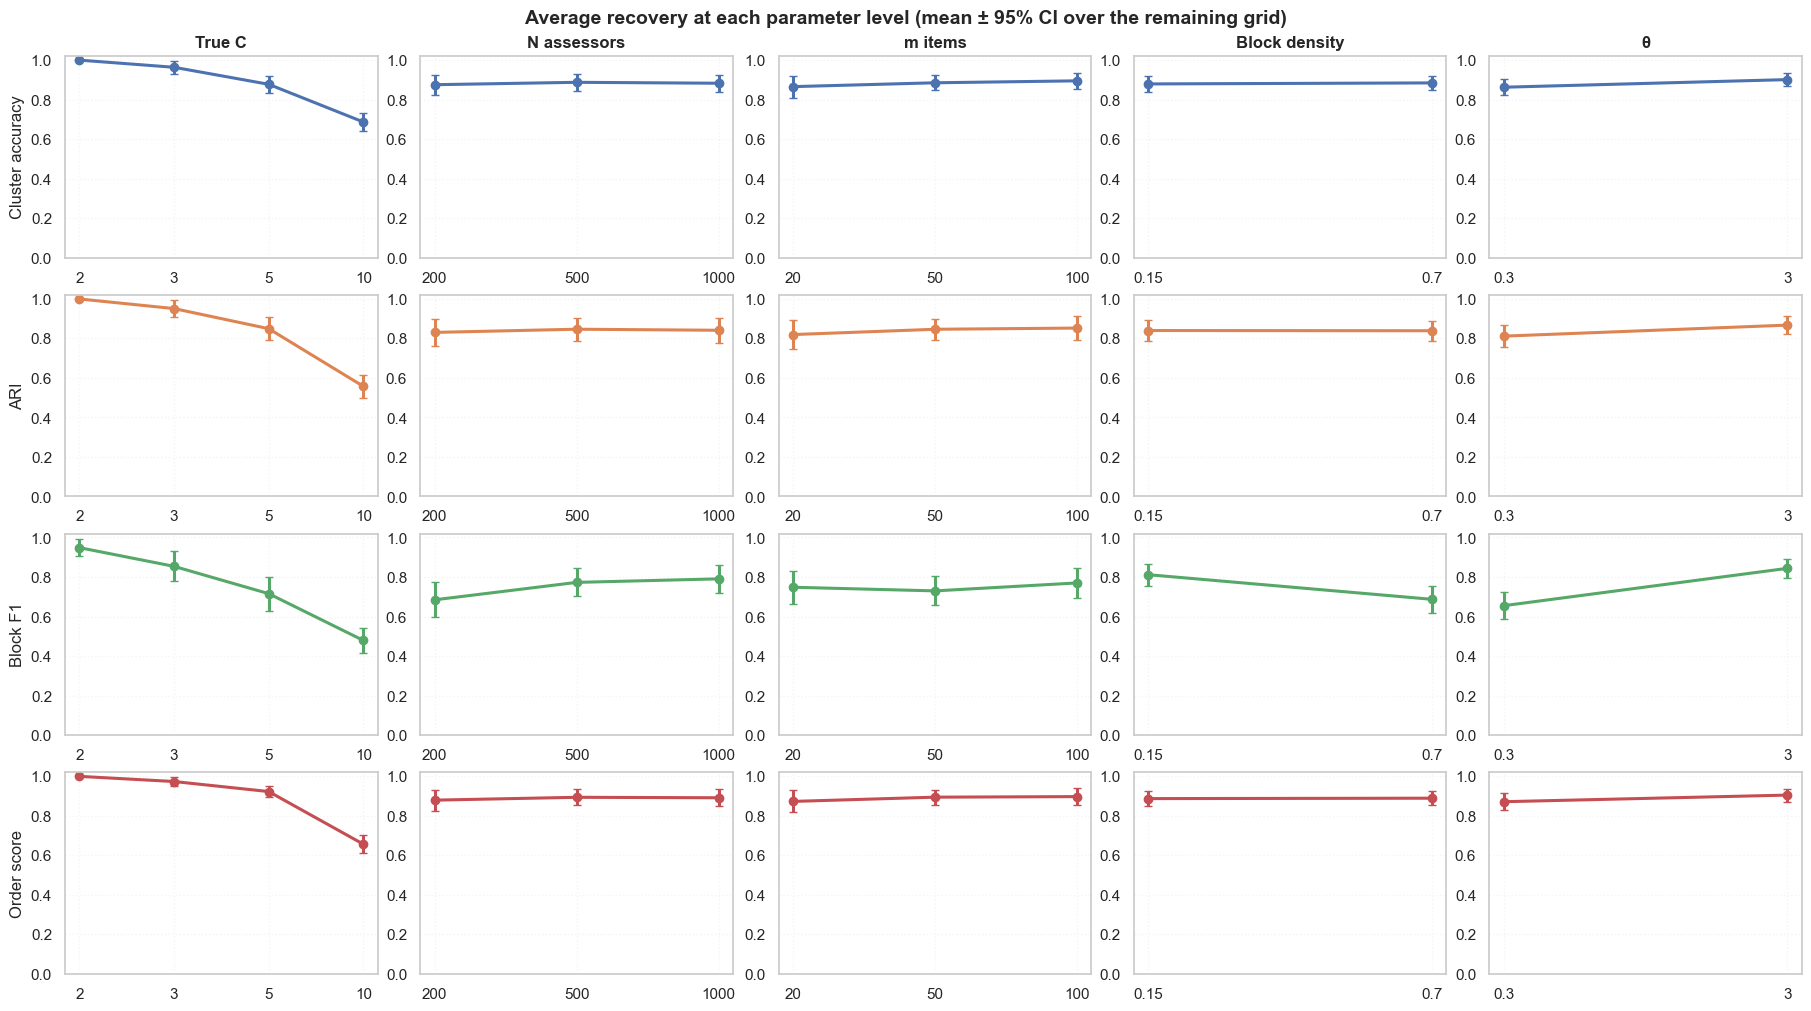

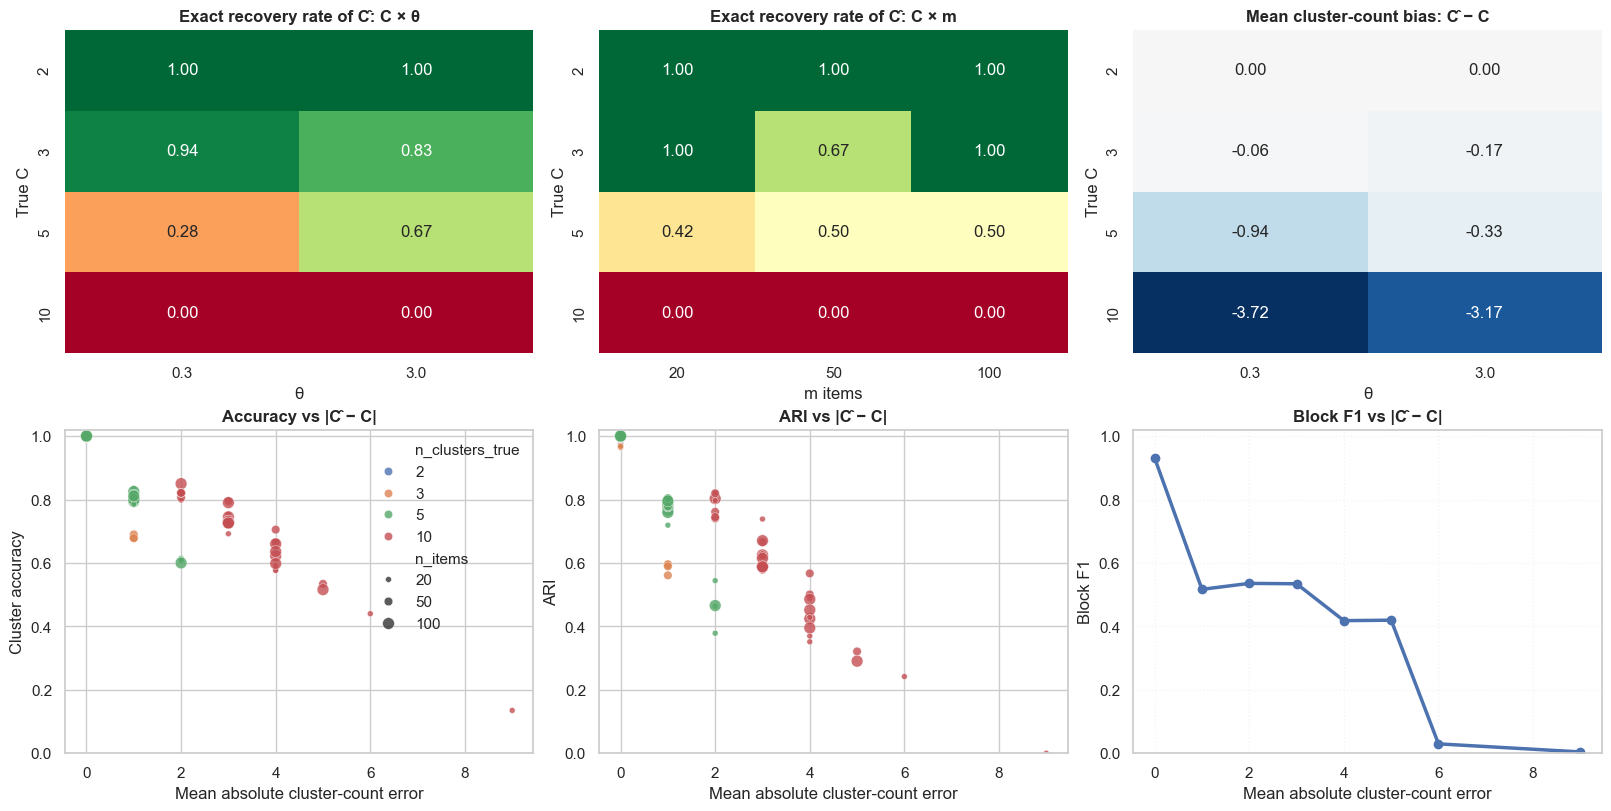

In [64]:
cluster_df = add_cluster_count_diagnostics(trial_df, summary_df)

show_parameter_grid(metadata, summary_df)
display_main_effect_tables(summary_df)
display_cluster_count_impact(cluster_df)
plot_main_effects(summary_df)
plot_cluster_count_diagnostics(cluster_df)

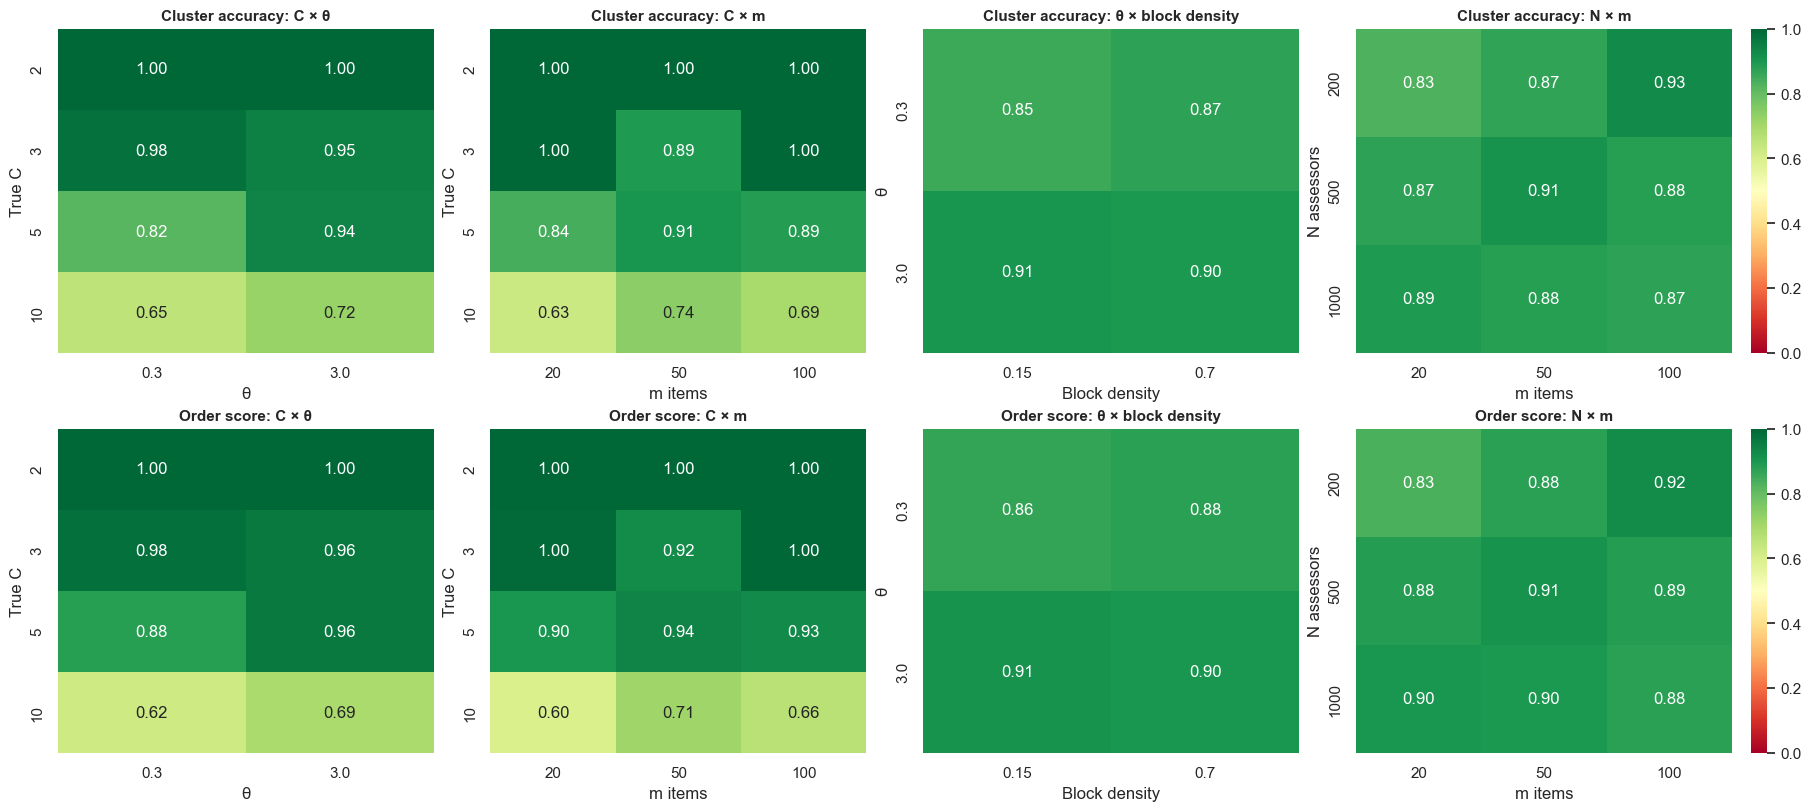

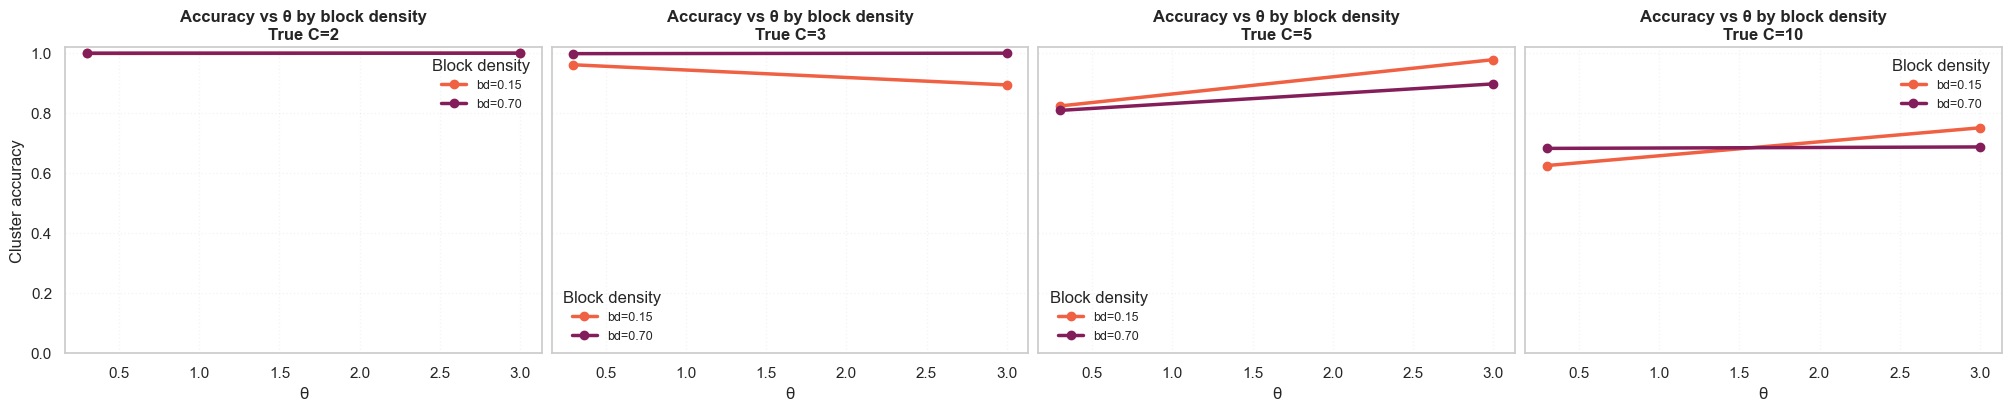

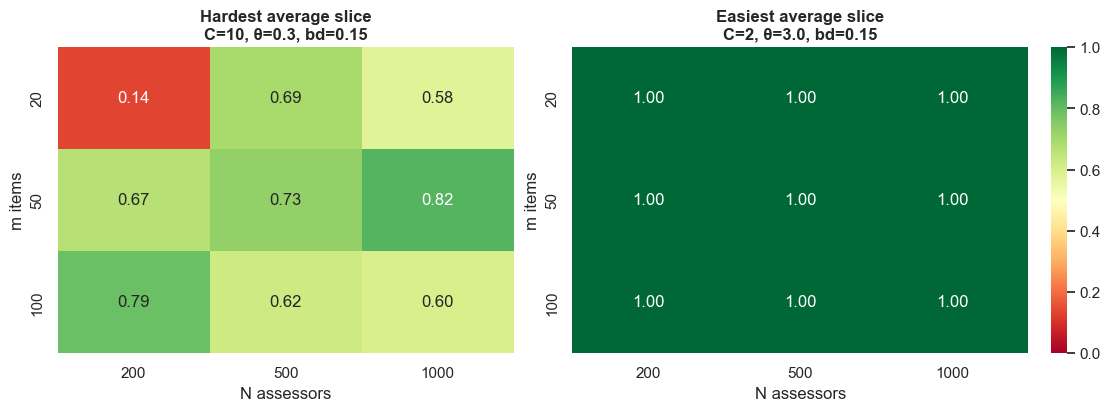

In [65]:
plot_interaction_heatmaps(summary_df)
plot_theta_density_slices(summary_df)
plot_extreme_nm_slices(summary_df)

## Follow-up stress test: rerun the hardest scenarios

This section re-runs the worst scenarios from the current simulation output using a longer chain and annealing during burn-in. The goal is to check whether some of the poor recovery was due to insufficient mixing rather than intrinsic difficulty.

In [ ]:
from _simulation_recovery_study import Scenario, run_scenario


def build_followup_scenario(row: pd.Series, trial_df: pd.DataFrame) -> Scenario:
    seed = int(trial_df.loc[trial_df['base_scenario'] == row['base_scenario'], 'seed'].iloc[0])
    return Scenario(
        name=f"{row['base_scenario']}_followup_seed{seed}",
        n_clusters=int(row['n_clusters_true']),
        n_assessors=int(row['n_assessors']),
        n_items=int(row['n_items']),
        theta=float(row['theta']),
        block_density=float(row['block_density']),
        seed=seed,
    )


def rerun_worst_scenarios(
    summary_df: pd.DataFrame,
    trial_df: pd.DataFrame,
    *,
    n_cases: int = 4,
    metric_key: str = 'aligned_cluster_accuracy',
    n_iter: int = 16000,
    burn_in: int = 10000,
    thin: int = 20,
    n_restarts: int = 4,
    use_annealing: bool = True,
    temp_min: float = 0.1,
    temp_max: float = 1.0,
) -> pd.DataFrame:
    baseline_col = metric_mean_col(metric_key)
    worst = summary_df.nsmallest(n_cases, baseline_col).copy()
    comparison_rows = []

    print(
        f'Rerunning {len(worst)} worst scenarios with n_iter={n_iter}, '
        f'burn_in={burn_in}, annealing={use_annealing}, temp_min={temp_min}'
    )

    for i, (_, row) in enumerate(worst.iterrows(), start=1):
        scenario = build_followup_scenario(row, trial_df)
        print(f'[{i}/{len(worst)}] {scenario.name}')
        rerun = run_scenario(
            scenario,
            n_iter=n_iter,
            burn_in=burn_in,
            thin=thin,
            n_restarts=n_restarts,
            use_annealing=use_annealing,
            temp_min=temp_min,
            temp_max=temp_max,
        )
        m = rerun['metrics']
        comparison_rows.append({
            'scenario': row['base_scenario'],
            'C': int(row['n_clusters_true']),
            'N': int(row['n_assessors']),
            'm_items': int(row['n_items']),
            'block_density': float(row['block_density']),
            'theta': float(row['theta']),
            'baseline_accuracy': float(row[metric_mean_col('aligned_cluster_accuracy')]),
            'rerun_accuracy': float(m['aligned_cluster_accuracy']),
            'baseline_ari': float(row[metric_mean_col('adjusted_rand_index')]),
            'rerun_ari': float(m['adjusted_rand_index']),
            'baseline_block_f1': float(row[metric_mean_col('weighted_same_block_f1')]),
            'rerun_block_f1': float(m['weighted_same_block_f1']),
            'baseline_order_score': 1.0 - float(row[metric_mean_col('weighted_normalized_kemeny_p_half')]),
            'rerun_order_score': 1.0 - float(m['weighted_normalized_kemeny_p_half']),
            'baseline_pred_clusters': float(row['n_pred_clusters_mean']),
            'rerun_pred_clusters': float(m['n_pred_clusters']),
            'runtime_seconds': float(rerun['runtime_seconds']),
        })

    compare_df = pd.DataFrame(comparison_rows)
    for metric in ['accuracy', 'ari', 'block_f1', 'order_score']:
        compare_df[f'delta_{metric}'] = compare_df[f'rerun_{metric}'] - compare_df[f'baseline_{metric}']
    compare_df['delta_pred_clusters'] = compare_df['rerun_pred_clusters'] - compare_df['baseline_pred_clusters']
    return compare_df.sort_values('delta_accuracy', ascending=False)


def plot_followup_comparison(compare_df: pd.DataFrame) -> None:
    metric_specs = [
        ('accuracy', 'Cluster accuracy'),
        ('ari', 'ARI'),
        ('block_f1', 'Block F1'),
        ('order_score', 'Order score'),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

    for ax, (metric_key, label) in zip(axes.flat, metric_specs):
        for _, row in compare_df.iterrows():
            ax.plot([0, 1], [row[f'baseline_{metric_key}'], row[f'rerun_{metric_key}']], marker='o', linewidth=2)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Original run', 'Longer + annealed'])
        ax.set_ylim(0, 1.02)
        ax.set_title(label, fontweight='bold')
        ax.grid(alpha=0.2, linestyle=':')

    fig.suptitle('Worst-case follow-up: does a longer annealed run help?', fontsize=14, fontweight='bold')
    plt.show()


followup_df = rerun_worst_scenarios(
    summary_df,
    trial_df,
    n_cases=4,
    n_iter=16000,
    burn_in=10000,
    thin=20,
    n_restarts=4,
    use_annealing=True,
    temp_min=0.1,
    temp_max=1.0,
)

followup_display = followup_df[[
    'scenario', 'C', 'N', 'm_items', 'block_density', 'theta',
    'baseline_accuracy', 'rerun_accuracy', 'delta_accuracy',
    'baseline_ari', 'rerun_ari', 'delta_ari',
    'baseline_block_f1', 'rerun_block_f1', 'delta_block_f1',
    'baseline_pred_clusters', 'rerun_pred_clusters', 'delta_pred_clusters',
    'runtime_seconds',
]].round(3)

display(followup_display)
print('Mean deltas across rerun cases:')
display(followup_df[[c for c in followup_df.columns if c.startswith('delta_')]].mean().to_frame('mean_delta').T.round(3))
plot_followup_comparison(followup_df)

## Ablation: annealing alone

This check keeps the original simulation budget and only switches annealing on. That isolates whether the gain came from annealing itself rather than from the longer run.

In [ ]:
def summarize_ablation(name: str, df: pd.DataFrame) -> dict[str, float]:
    return {
        'setting': name,
        'mean Δ accuracy': df['delta_accuracy'].mean(),
        'mean Δ ARI': df['delta_ari'].mean(),
        'mean Δ Block F1': df['delta_block_f1'].mean(),
        'mean Δ order score': df['delta_order_score'].mean(),
        'mean Δ predicted clusters': df['delta_pred_clusters'].mean(),
    }


def plot_ablation_summary(ablation_df: pd.DataFrame) -> None:
    metric_cols = ['mean Δ accuracy', 'mean Δ ARI', 'mean Δ Block F1', 'mean Δ order score']
    plot_df = ablation_df.set_index('setting')[metric_cols]
    ax = plot_df.plot(kind='bar', figsize=(10, 5), ylim=(0, 1.05), rot=0)
    ax.set_ylabel('Average improvement over original run')
    ax.set_title('How much improvement comes from annealing alone?', fontweight='bold')
    ax.grid(axis='y', alpha=0.2, linestyle=':')
    plt.tight_layout()
    plt.show()


base_n_iter = int(summary_df['n_iter'].iloc[0])
base_burn_in = int(summary_df['burn_in'].iloc[0])
base_thin = int(summary_df['thin'].iloc[0])
base_restarts = int(summary_df['n_restarts'].iloc[0])

anneal_only_df = rerun_worst_scenarios(
    summary_df,
    trial_df,
    n_cases=4,
    n_iter=base_n_iter,
    burn_in=base_burn_in,
    thin=base_thin,
    n_restarts=base_restarts,
    use_annealing=True,
    temp_min=0.1,
    temp_max=1.0,
)

anneal_only_display = anneal_only_df[[
    'scenario', 'baseline_accuracy', 'rerun_accuracy', 'delta_accuracy',
    'baseline_ari', 'rerun_ari', 'delta_ari',
    'baseline_block_f1', 'rerun_block_f1', 'delta_block_f1',
    'baseline_pred_clusters', 'rerun_pred_clusters', 'delta_pred_clusters',
]].round(3)

print('Annealing only, keeping the original iteration budget')
display(anneal_only_display)

ablation_df = pd.DataFrame([
    summarize_ablation('Annealing only', anneal_only_df),
    summarize_ablation('Longer + annealed', followup_df),
]).round(3)

print('Average gain across the same worst scenarios')
display(ablation_df)
plot_ablation_summary(ablation_df)

## Iteration sensitivity on a deliberately hard dataset

This section fixes one difficult synthetic scenario and re-fits the model over a range of iteration budgets. The goal is to identify the point after which the performance is essentially unchanged.

Running n_iter=1000, burn_in=600
Running n_iter=2000, burn_in=1200
Running n_iter=3000, burn_in=1800
Running n_iter=5000, burn_in=3000
Running n_iter=8000, burn_in=4800
Running n_iter=12000, burn_in=7200
Hard scenario tested:


,C,N,m_items,block_density,theta,seed
0,5,200,100,0.7,0.3,2026


,n_iter,burn_in,accuracy,ARI,Block F1,order_score,pred_clusters,runtime_seconds,max_gap_to_final
0,1000,600,1.000,1.000,0.380,0.994,5,15.988,0.179
1,2000,1200,1.000,1.000,0.386,0.993,5,20.442,0.179
2,3000,1800,1.000,1.000,0.378,0.993,5,27.999,0.179
3,5000,3000,1.000,1.000,0.393,0.994,5,61.848,0.179
4,8000,4800,0.845,0.821,0.271,0.907,4,85.520,0.015
5,12000,7200,0.845,0.821,0.256,0.907,4,85.277,0.000


Performance is essentially unaffected from about n_iter=8000 onward (tolerance 0.03).


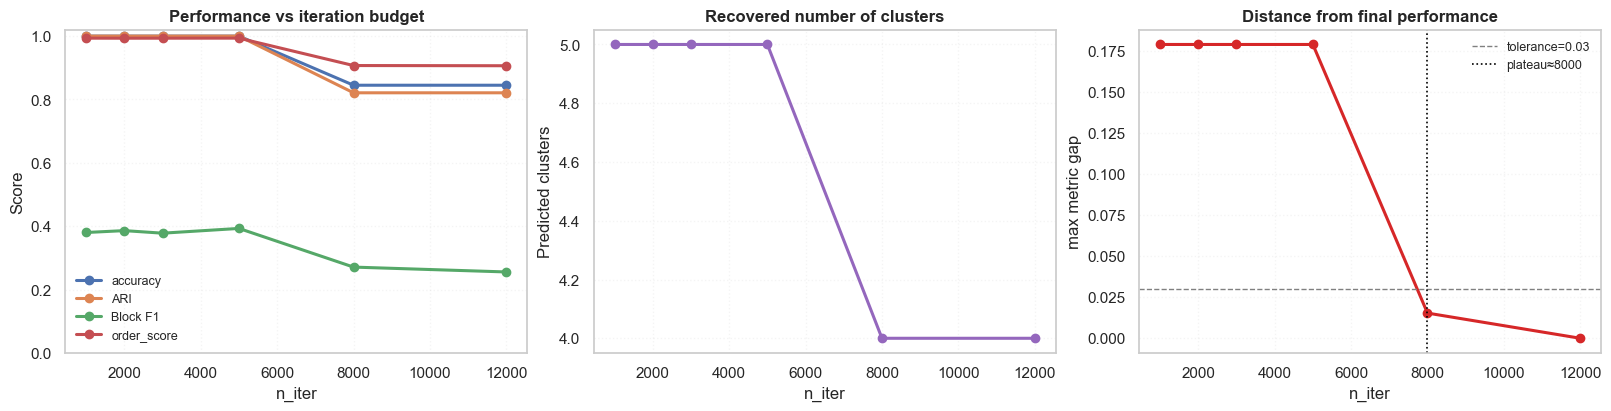

In [47]:
HARD_SCENARIO = Scenario(
    name='iter_sensitivity_c5_n200_m100_bd0p70_theta0p3_seed2026',
    n_clusters=5,
    n_assessors=200,
    n_items=100,
    theta=0.3,
    block_density=0.70,
    seed=2026,
)

ITER_GRID = [1000, 2000, 3000, 5000, 8000, 12000]
PLATEAU_TOL = 0.03


def iteration_sensitivity_experiment(
    scenario: Scenario,
    iter_grid: list[int],
    *,
    burn_frac: float = 0.6,
    thin: int = 20,
    n_restarts: int = 3,
    use_annealing: bool = True,
    temp_min: float = 0.1,
    temp_max: float = 1.0,
) -> tuple[pd.DataFrame, int | None]:
    rows = []
    for n_iter in iter_grid:
        burn_in = min(int(round(burn_frac * n_iter)), n_iter - thin)
        print(f'Running n_iter={n_iter}, burn_in={burn_in}')
        result = run_scenario(
            scenario,
            n_iter=n_iter,
            burn_in=burn_in,
            thin=thin,
            n_restarts=n_restarts,
            use_annealing=use_annealing,
            temp_min=temp_min,
            temp_max=temp_max,
        )
        metrics = result['metrics']
        rows.append({
            'n_iter': n_iter,
            'burn_in': burn_in,
            'accuracy': metrics['aligned_cluster_accuracy'],
            'ARI': metrics['adjusted_rand_index'],
            'Block F1': metrics['weighted_same_block_f1'],
            'order_score': 1.0 - metrics['weighted_normalized_kemeny_p_half'],
            'pred_clusters': metrics['n_pred_clusters'],
            'runtime_seconds': result['runtime_seconds'],
        })

    df = pd.DataFrame(rows)
    final = df.iloc[-1]
    metric_cols = ['accuracy', 'ARI', 'Block F1', 'order_score']
    df['max_gap_to_final'] = df[metric_cols].sub(final[metric_cols], axis=1).abs().max(axis=1)

    plateau_iter = None
    stable_mask = df['max_gap_to_final'] <= PLATEAU_TOL
    if stable_mask.any():
        plateau_iter = int(df.loc[stable_mask, 'n_iter'].iloc[0])
    return df, plateau_iter


def plot_iteration_sensitivity(df: pd.DataFrame, plateau_iter: int | None = None) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

    for metric in ['accuracy', 'ARI', 'Block F1', 'order_score']:
        axes[0].plot(df['n_iter'], df[metric], marker='o', linewidth=2.2, label=metric)
    axes[0].set_title('Performance vs iteration budget', fontweight='bold')
    axes[0].set_xlabel('n_iter')
    axes[0].set_ylabel('Score')
    axes[0].set_ylim(0, 1.02)
    axes[0].grid(alpha=0.2, linestyle=':')
    axes[0].legend(fontsize=9)

    axes[1].plot(df['n_iter'], df['pred_clusters'], marker='o', linewidth=2.2, color='tab:purple')
    axes[1].set_title('Recovered number of clusters', fontweight='bold')
    axes[1].set_xlabel('n_iter')
    axes[1].set_ylabel('Predicted clusters')
    axes[1].grid(alpha=0.2, linestyle=':')

    axes[2].plot(df['n_iter'], df['max_gap_to_final'], marker='o', linewidth=2.2, color='tab:red')
    axes[2].axhline(PLATEAU_TOL, linestyle='--', color='grey', linewidth=1, label=f'tolerance={PLATEAU_TOL:.2f}')
    if plateau_iter is not None:
        axes[2].axvline(plateau_iter, linestyle=':', color='black', linewidth=1.2, label=f'plateau≈{plateau_iter}')
    axes[2].set_title('Distance from final performance', fontweight='bold')
    axes[2].set_xlabel('n_iter')
    axes[2].set_ylabel('max metric gap')
    axes[2].grid(alpha=0.2, linestyle=':')
    axes[2].legend(fontsize=9)

    plt.show()


iter_df, plateau_iter = iteration_sensitivity_experiment(
    HARD_SCENARIO,
    ITER_GRID,
    burn_frac=0.6,
    thin=20,
    n_restarts=3,
    use_annealing=True,
    temp_min=0.1,
    temp_max=1.0,
)

print('Hard scenario tested:')
display(pd.DataFrame([{
    'C': HARD_SCENARIO.n_clusters,
    'N': HARD_SCENARIO.n_assessors,
    'm_items': HARD_SCENARIO.n_items,
    'block_density': HARD_SCENARIO.block_density,
    'theta': HARD_SCENARIO.theta,
    'seed': HARD_SCENARIO.seed,
}]))

display(iter_df.round(3))
if plateau_iter is None:
    print(f'No clear plateau under tolerance {PLATEAU_TOL:.2f} in the tested range.')
else:
    print(f'Performance is essentially unaffected from about n_iter={plateau_iter} onward (tolerance {PLATEAU_TOL:.2f}).')
plot_iteration_sensitivity(iter_df, plateau_iter)

In [36]:
BREAK_THRESHOLD = 0.8
break_df = failure_table(summary_df, metric_key='aligned_cluster_accuracy', threshold=BREAK_THRESHOLD)

print(f'Scenarios with mean accuracy below {BREAK_THRESHOLD:.2f}')
display(break_df.round(3))

Scenarios with mean accuracy below 0.80


,base_scenario,n_clusters_true,n_assessors,n_items,block_density,theta,aligned_cluster_accuracy_mean,adjusted_rand_index_mean,weighted_normalized_kemeny_p_half_mean,weighted_same_block_f1_mean,weighted_block_count_error_mean
0,c2_n100_m10_bd0p15_theta0p4,2,100,10,0.15,0.4,0.520,0.000,0.257,0.389,3.440
24,c2_n100_m24_bd0p15_theta0p4,2,100,24,0.15,0.4,0.560,0.000,0.223,0.203,8.640
36,c2_n300_m10_bd0p15_theta0p4,2,300,10,0.15,0.4,0.547,0.000,0.261,0.506,1.547
60,c2_n300_m24_bd0p15_theta0p4,2,300,24,0.15,0.4,0.553,0.000,0.263,0.193,7.127
72,c2_n700_m10_bd0p15_theta0p4,2,700,10,0.15,0.4,0.523,0.000,0.262,0.404,2.431
...,...,...,...,...,...,...,...,...,...,...,...
251,c5_n100_m24_bd0p70_theta4p0,5,100,24,0.70,4.0,0.250,0.000,0.421,0.038,2.960
275,c5_n300_m16_bd0p70_theta4p0,5,300,16,0.70,4.0,0.413,0.191,0.349,0.252,0.603
287,c5_n300_m24_bd0p70_theta4p0,5,300,24,0.70,4.0,0.230,0.000,0.461,0.130,3.037
311,c5_n700_m16_bd0p70_theta4p0,5,700,16,0.70,4.0,0.414,0.209,0.334,0.331,0.603


## Notes

For a completed grid run, this notebook is most useful when you switch `RUN_NAME` to the grid directory and then:

- scan the theta sweeps to see how recovery changes with dispersion
- use the heatmap cell for fixed `(C, theta)` slices
- inspect the failure table to identify the exact parameter combinations where the model starts to break